# Lung Ultrasound -- Ultrasound Agent (pulmonary module)

## Objective

**Detect clinically relevant lung findings from POCUS clips and report a calibrated confidence for
each.** Not a diagnosis. A radiologist writes *"multiple B-lines, small consolidation, no pleural
effusion"* -- the leap to *"pneumonia"* belongs to the Clinical Reasoning Agent, which has the
vitals, the labs and the history that this module never sees.

The output is therefore a **list of findings with per-finding confidence**, never a disease label:

```json
{"organ": "lung",
 "findings": [{"label": "consolidation", "confidence": 0.82},
              {"label": "b lines",       "confidence": 0.74}],
 "not_detected": ["pleural effusion", "pleural thickening"]}
```

Multi-label is the correct formulation and is kept: consolidation and effusion genuinely co-occur.

## What the first case-grouped run revealed

Fold 0 came back at AUROC 0.701 / 0.787 / 0.566 / 0.757 -- down from the 0.745-0.808 reported
before, exactly as expected once clip-level leakage and in-fold threshold tuning were removed.

But the training curve showed something else: **train loss fell to 0.47 while val loss climbed
from 0.90 to 1.10 from epoch 3 onward**, and the run trained only

    Trainable parameters: ['head.weight', 'head.bias']  (5,124 total)

The entire backbone was frozen. A 5,124-parameter linear probe was sitting on **unadapted ImageNet
features**, and ultrasound speckle resembles natural images very little. That is the single
largest constraint on this module, larger than the head or the augmentation, and it is addressed
below.

## Changes in this revision

| Change | Reason |
|---|---|
| **Unfreeze the backbone** (last blocks, low LR) | a frozen ImageNet probe cannot adapt to ultrasound texture |
| Deeper head with dropout | richer than a bare linear layer, costs almost nothing |
| Ultrasound-specific augmentation | gain, gamma, speckle, zoom -- and *no* large rotations, which do not occur in acquisition |
| **Median** frame aggregation | one bad frame should not dominate a clip |
| Early stopping | val loss rises from epoch 3; the remaining epochs were cost without benefit |
| Per-finding sensitivity / specificity / ECE | each finding is independent and is reported that way |
| Grad-CAM measured, not eyeballed | centroid spread, area and entropy, as in the gallbladder module |

**Pleural effusion has only 24 positives** and scored AUROC 0.566 on fold 0 -- barely above chance.
It is reported with an explicit unreliability flag rather than silently emitted as if it carried
the same weight as the others.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q opencv-python-headless imageio scikit-learn down


Mounted at /content/drive
  Preparing metadata (setup.py) ... done


In [2]:
import io
import json
import zipfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

DRIVE_ROOT = Path('/content/drive/MyDrive/POCUS-Project')
MANIFEST_PATH = DRIVE_ROOT / 'manifests' / 'pulmonary_manifest.csv'
DATA_ROOT = DRIVE_ROOT / 'Pulmonary' / 'POCUS_extracted'
USCL_CKPT = DRIVE_ROOT / 'Pulmonary' / 'USCL_weights' / 'checkpoint' / 'best_model.pth'

FINDING_COLS = ['finding_b_lines', 'finding_consolidation', 'finding_pleural_effusion', 'finding_pleural_thickening']
FRAMES_PER_CLIP = 8
IMG_SIZE = 224
BATCH_SIZE = 32       # 16 -> 32: half the optimizer steps, better GPU occupancy
EPOCHS = 15          # upper bound; early stopping (section 7) normally ends sooner
DEV_MODE = False       # True  -> ONE 80/20 split, for iterating on the model
                      # False -> full GroupKFold, for the numbers you report
NUM_WORKERS = 2       # 0 (the default) left the GPU idle waiting on CPU augmentation
PATIENCE = 3         # stop after this many epochs with no val-AUROC improvement.
                     # The previous run showed val loss rising from epoch 3 while
                     # train loss kept falling -- those epochs cost time, not skill.
LR = 1e-3

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

def set_seed(seed=42):
    # Data augmentation (random crop/flip) and DataLoader shuffling aren't seeded by default,
    # so re-running the same cell gives different numbers each time -- this pins that down so
    # runs (and the 3-way comparison) are reproducible.
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


Device: cuda


## 2. Load and filter the manifest

Drops rows already flagged by the manifest itself (`flag_do_not_use`, `flag_off_target_organ`),
and builds the multi-label target array from the 4 finding columns.


In [3]:
df = pd.read_csv(MANIFEST_PATH)
df = df[~df['flag_do_not_use'] & ~df['flag_off_target_organ']].reset_index(drop=True)
df['filepath'] = df['filepath'].str.replace('\\', '/', regex=False)
df['labels'] = df[FINDING_COLS].astype(int).values.tolist()

print(f'{len(df)} clips/images after filtering')
print(df[FINDING_COLS].sum())


187 clips/images after filtering
finding_b_lines               63
finding_consolidation         60
finding_pleural_effusion      24
finding_pleural_thickening    46
dtype: int64


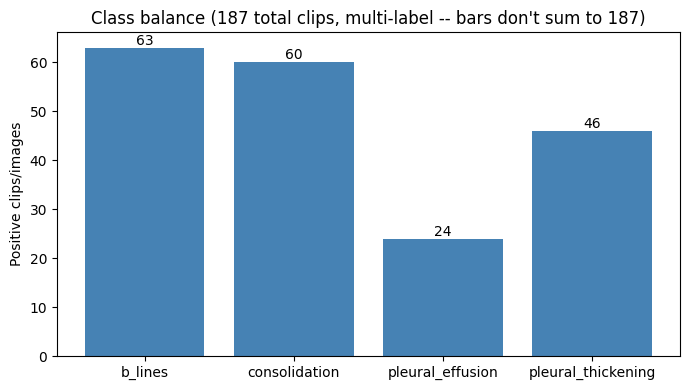

Clips with no finding at all: 87 (47%)
Note the effusion/thickening minority -- this is why pos_weight and threshold tuning show up later in training/eval.


In [4]:
label_counts = df[FINDING_COLS].sum()
n_no_finding = (df[FINDING_COLS].sum(axis=1) == 0).sum()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([c.replace("finding_", "") for c in FINDING_COLS], label_counts.values, color="steelblue")
ax.bar_label(bars)
ax.set_ylabel("Positive clips/images")
ax.set_title(f"Class balance ({len(df)} total clips, multi-label -- bars don't sum to {len(df)})")
plt.tight_layout()
plt.show()

print(f"Clips with no finding at all: {n_no_finding} ({n_no_finding/len(df):.0%})")
print("Note the effusion/thickening minority -- this is why pos_weight and threshold tuning show up later in training/eval.")


## 3. Train/val split -- grouped by case, not by clip

Frames from one clip are near-duplicates, so the split must be above frame level. That much the
previous version had right. What it missed is that **several clips come from the same patient**,
and grouping only by clip lets that patient appear on both sides of the split.

The evidence is in the filenames, and two of the groups span disease classes:

| Case | Clips | Classes |
|---|---|---|
| `denault_proposedus_series` | 8 | covid19 |
| `new_pregnant_series` | 7 | **covid19 + healthy** |
| `case3` | 5 | **bacterial_pneumonia + healthy** |
| `atlas_dayseries` | 4 | covid19 |
| `case2` | 2 | viral_pneumonia |
| `nephropocus` | 2 | healthy |

`GroupKFold` on the derived case key guarantees no case spans folds, and every case is held out
exactly once -- so pooling the out-of-fold predictions covers all clips with none double-counted.

Stratification is lost by moving to `GroupKFold` (it cannot stratify and group at once at this
size). The per-fold label balance is printed below so any severe imbalance is visible rather than
assumed away.


In [5]:
import re
from sklearn.model_selection import GroupKFold

# Source tokens name a provider, not a patient -- never group on them alone.
GENERIC_TOKENS = {'avi', 'clarius', 'youtube', 'grep', 'video', 'image', 'butterfly', 'pocus'}


def case_key(filename, disease_class):
    """Derive a patient/case identifier from the filename.

    Groups ONLY on explicit within-series markers, because over-grouping is not free: an earlier
    rule that stripped any trailing digits merged 21 unrelated clips into one 'case'.
    The class prefix (Cov_/Pneu_/Reg_/Vir_) is stripped first, since the same patient appears
    under different prefixes -- that is precisely the leak being closed.
    """
    stem = re.sub(r'\.[a-z0-9]+$', '', str(filename), flags=re.I)
    core = re.sub(r'^(cov|pneu|reg|vir)[-_]', '', stem, flags=re.I).lower()
    core = core.replace('-', '_').replace('+', '_')

    m = re.search(r'case(\d+)', core)
    if m:
        return f'case{m.group(1)}'                      # explicit case numbering
    m = re.match(r'(.*?)_?day_?\d+$', core)
    if m:
        return f'{m.group(1)}_dayseries'                # same patient across days
    m = re.match(r'(.*?)_?(?:vid|clip)_?\d+$', core)
    if m:
        base = m.group(1).strip('_')
        if len(base) > 6 and base.split('_')[0] not in GENERIC_TOKENS:
            return f'{base}_series'                     # distinctively named series
    return f'{disease_class}::{core}'                   # otherwise its own case


df['case'] = [case_key(f, c) for f, c in zip(df['filename'], df['class'])]
n_cases = df['case'].nunique()
print(f'{len(df)} clips -> {n_cases} independent cases')

multi = [(c, g) for c, g in df.groupby('case') if len(g) > 1]
print(f'{len(multi)} multi-clip cases, absorbing {sum(len(g) for _, g in multi)} clips:')
for c, g in sorted(multi, key=lambda x: -len(x[1])):
    cls = sorted(g['class'].unique())
    flag = '   <-- spans disease classes' if len(cls) > 1 else ''
    print(f'   {c:<30} {len(g)} clips  {cls}{flag}')

# Development runs one split; reporting runs the full partition. Both group by case, so the
# leakage guarantee is identical -- DEV_MODE changes how MUCH you measure, never how honestly.
# What it costs: one split scores ~37 cases instead of all 165, so estimates are noisier, and
# out-of-fold pooling (Sections 10-11) needs full coverage and will refuse to run.
# Never report a DEV_MODE number.
N_CV_SPLITS = 3
if DEV_MODE:
    from sklearn.model_selection import GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    cv_splits = list(gss.split(df, groups=df['case']))
    print('DEV_MODE: a single 80/20 split by case.')
    print('Set DEV_MODE = False in Section 1 for the reportable cross-validated run.')
else:
    gkf = GroupKFold(n_splits=N_CV_SPLITS)
    cv_splits = list(gkf.split(df, groups=df['case']))

print(f'\n{len(cv_splits)} split(s), grouped by case:')
for i, (tr, va) in enumerate(cv_splits):
    leak = set(df['case'].iloc[tr]) & set(df['case'].iloc[va])
    assert not leak, f'case leakage in fold {i}: {leak}'
    pos = df[FINDING_COLS].iloc[va].sum().to_dict()
    print(f'  fold {i}: {len(tr):3d} train / {len(va):3d} val clips | '
          f'{df["case"].iloc[va].nunique():3d} val cases | val positives {pos}')
print('\nNo case appears in both train and val in any fold.')


187 clips -> 165 independent cases
6 multi-clip cases, absorbing 28 clips:
   denault_proposedus_series      8 clips  ['covid19']
   new_pregnant_series            7 clips  ['covid19', 'healthy']   <-- spans disease classes
   case3                          5 clips  ['bacterial_pneumonia', 'healthy']   <-- spans disease classes
   atlas_dayseries                4 clips  ['covid19']
   case2                          2 clips  ['viral_pneumonia']
   healthy::nephropocus           2 clips  ['healthy']

3 split(s), grouped by case:
  fold 0: 124 train /  63 val clips |  55 val cases | val positives {'finding_b_lines': 20, 'finding_consolidation': 23, 'finding_pleural_effusion': 7, 'finding_pleural_thickening': 14}
  fold 1: 125 train /  62 val clips |  55 val cases | val positives {'finding_b_lines': 20, 'finding_consolidation': 19, 'finding_pleural_effusion': 5, 'finding_pleural_thickening': 15}
  fold 2: 125 train /  62 val clips |  55 val cases | val positives {'finding_b_lines': 23, 'fi

## 4. Frame extraction

Videos are a mix of mp4/avi/mov/mpeg (OpenCV) and gif (OpenCV can't read these — falls back to
imageio). Images pass through as a single frame. Samples `FRAMES_PER_CLIP` evenly spaced frames
per clip — nearby frames in an ultrasound clip are near-identical for a texture-based task, so
more than ~8 buys little.


In [6]:
def extract_frames(filepath: Path, media_type: str, n_frames: int) -> list:
    if media_type == 'image':
        return [np.array(Image.open(filepath).convert('RGB'))]

    suffix = filepath.suffix.lower()
    if suffix == '.gif':
        frames = imageio.mimread(str(filepath))
        frames = [np.array(Image.fromarray(f).convert('RGB')) for f in frames]
    else:
        cap = cv2.VideoCapture(str(filepath))
        frames = []
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        cap.release()

    if not frames:
        return []
    idx = np.linspace(0, len(frames) - 1, min(n_frames, len(frames))).astype(int)
    return [frames[i] for i in idx]


## 5. Dataset

`FrameCache` decodes every kept clip's frames **once**, over the full 187-clip manifest — frame
decoding is the slow part, and it doesn't need to be redone per split or per backbone, only which
clips are assigned to train vs val changes between them. Each frame carries a `clip_pos` back to
its row position in `df` so it can be reassigned to whichever fold needs it.

`ClipSubset` is a thin view over `FrameCache` restricted to one split's `train_pos`/`val_pos`
clip positions, with its own transform and clip ids renumbered to a contiguous `0..n-1` range (so
`aggregate_by_clip` — section 7 — works correctly per fold).


In [7]:
class FrameCache(Dataset):
    """Decodes every kept clip's frames once, over the full filtered manifest. Frames carry
    clip_pos = their row position in `df`, stable across every split -- so a fold only has to
    pick which positions go to train vs val, no re-decoding needed."""
    def __init__(self, manifest_df: pd.DataFrame, transform):
        self.transform = transform
        self.samples = []
        clip_pos = 0
        for _, row in manifest_df.iterrows():
            filepath = DATA_ROOT / row['filepath']
            if not filepath.exists():
                print('Missing file, skipping:', filepath)
                continue
            frames = extract_frames(filepath, row['media_type'], FRAMES_PER_CLIP)
            if not frames:
                continue
            label = np.array(row['labels'], dtype=np.float32)
            for frame in frames:
                self.samples.append((frame, label, clip_pos))
            clip_pos += 1
        self.num_clips = clip_pos

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame, label, clip_pos = self.samples[idx]
        image = self.transform(Image.fromarray(frame))
        return image, torch.from_numpy(label), clip_pos


class ClipSubset(Dataset):
    """View over FrameCache restricted to one split's clip positions. Renumbers clip ids to a
    contiguous 0..n-1 range (matching how many *clips*, not frames, are in this fold) so
    aggregate_by_clip works per fold. `global_positions[i]` maps a local clip id i back to its
    row position in `df`, so per-clip predictions can be pooled back into a full-dataset array
    (section 9/10) instead of only ever being seen inside their own fold. Every sample also
    carries a mask of all-ones -- this dataset's labels are always fully known; the mask only
    matters for LUS-BALD (below), which isn't."""
    def __init__(self, frame_cache: 'FrameCache', clip_positions, transform):
        self.transform = transform
        wanted = set(int(p) for p in clip_positions)
        self.global_positions = sorted(wanted)
        remap = {pos: i for i, pos in enumerate(self.global_positions)}
        self.samples = [(frame, label, remap[pos]) for frame, label, pos in frame_cache.samples if pos in wanted]
        self.num_clips = len(remap)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame, label, clip_idx = self.samples[idx]
        image = self.transform(Image.fromarray(frame))
        mask = torch.ones(len(FINDING_COLS), dtype=torch.float32)
        return image, torch.from_numpy(label), clip_idx, mask


# Normalization has to match what each backbone was actually pretrained with: USCL used
# mean/std=0.5/0.25 (not ImageNet stats), while a real torchvision ImageNet checkpoint expects
NORM_STATS = {
    'uscl': ([0.5, 0.5, 0.5], [0.25, 0.25, 0.25]),
    'imagenet': ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    'efficientnet_b0': ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
}


class SpeckleNoise:
    """Multiplicative speckle -- the physically correct ultrasound noise model, where noise scales
    with signal. Additive Gaussian noise would be the wrong process, and blur would push training
    data away from what real acquisitions look like rather than toward it."""
    def __init__(self, sigma=0.12, p=0.5):
        self.sigma, self.p = sigma, p

    def __call__(self, x):
        if torch.rand(1).item() > self.p:
            return x
        return (x + x * torch.randn_like(x) * self.sigma).clamp(0, 1)


class GammaJitter:
    """Gamma reshapes mid-tones nonlinearly. Brightness/contrast jitter is affine and cannot
    reproduce the TGC and dynamic-range differences between machines; gamma can."""
    def __init__(self, lo=0.7, hi=1.4, p=0.5):
        self.lo, self.hi, self.p = lo, hi, p

    def __call__(self, x):
        if torch.rand(1).item() > self.p:
            return x
        g = torch.empty(1).uniform_(self.lo, self.hi).item()
        return x.clamp(1e-6, 1.0) ** g


def make_transforms(norm_mean, norm_std):
    # Ultrasound-specific, and deliberately NOT rotation-heavy: a probe is held in a consistent
    # orientation, so a 15-degree rotation invents images the scanner cannot produce. Gain, gamma,
    # speckle and small zoom reproduce differences that DO occur between machines and operators.
    train_transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1)),   # small zoom/crop
        T.RandomHorizontalFlip(),
        T.RandomAffine(degrees=5, translate=(0.05, 0.05)),                     # slight probe tilt only
        T.ColorJitter(brightness=0.3, contrast=0.3),                           # gain / TGC
        T.ToTensor(),
        GammaJitter(0.7, 1.4, p=0.5),
        SpeckleNoise(sigma=0.12, p=0.5),
        T.Normalize(mean=norm_mean, std=norm_std),
    ])
    val_transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=norm_mean, std=norm_std),
    ])
    return train_transform, val_transform


# Frame decoding (the slow part) happens once here, with a placeholder transform -- reused across
# every split and every backbone in section 9 via build_dataloaders() below.
_placeholder_t, _ = make_transforms(*NORM_STATS['imagenet'])
frame_cache = FrameCache(df, _placeholder_t)
print(f'Decoded {len(frame_cache)} frames from {frame_cache.num_clips} clips (decoded once, reused across every split and backbone)')


from torch.utils.data import ConcatDataset


def build_dataloaders(backbone_name, train_pos, val_pos):
    train_transform, val_transform = make_transforms(*NORM_STATS[backbone_name])
    train_dataset = ClipSubset(frame_cache, train_pos, train_transform)
    val_dataset = ClipSubset(frame_cache, val_pos, val_transform)
    # LUS-BALD is added to every fold's TRAIN loader only (see the markdown below this section) --
    # never held out, never validated on. train_dataset itself (returned separately) stays the
    # plain ClipSubset so pos_weight (section 7) can still read its .samples the same way as before.
    extra_train_dataset = ExtraLabelDataset(lus_bald_images, lus_bald_labels, lus_bald_masks, train_transform)
    combined_train_dataset = ConcatDataset([train_dataset, extra_train_dataset])
    train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True,
                              persistent_workers=NUM_WORKERS > 0, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                            pin_memory=True, persistent_workers=NUM_WORKERS > 0)
    return train_dataset, train_loader, val_dataset, val_loader


Decoded 1181 frames from 187 clips (decoded once, reused across every split and backbone)


### Supplementary training-only data — LUS-BALD (B-lines only, no negatives)

[Orvile's Kaggle "Lung Ultrasound Imaging Dataset for Accurate Detection and Localization of
B-line Artifacts"](https://www.kaggle.com/datasets/orvile/lung-ultrasound-imaging-dataset)
(CC BY 4.0), 401 images from 255 patients in Uganda -- a genuinely different population from the
POCUS Atlas/Butterfly sources `df` is built from. Inspecting the actual zip (not just the Kaggle
description) turned up two things that shape how this can be used:

- Its `test` split (70 images) ships with **no label files at all** -- unusable here.
- Every one of the 331 labeled images (`train` + `val`) is **B-lines positive** -- there isn't a
  single negative example in this dataset, and nothing at all is known about the other 3 findings
  for these images.

That means it can't function as its own independent train/val/test set (no negatives to learn or
validate against). Instead: **all 331 images are added to every fold's training set only** (never
held out, never validated on -- validation/test stay 100% `df`-sourced, exactly as before), and
each carries a **mask** alongside its label so the training loss only scores the column actually
known for that image (b_lines) and skips the other 3, rather than guessing them as negative.
`pos_weight` (section 7) is recomputed to include LUS-BALD's contribution to the b_lines column
only, since the other 3 columns' true counts are unaffected by images we have no information on.

**Before running**: upload `Pulmonary/LUS-BALD/LUS-BALD.zip` to Drive, same relative path as
everything else.


In [8]:
LUS_BALD_ZIP = DRIVE_ROOT / 'Pulmonary' / 'LUS-BALD' / 'LUS-BALD.zip'
LUS_BALD_ROOT = 'Lung Ultrasound Imaging Dataset for Accurate Detection and Localization of B-line Artifacts/LUS-BALD/LUS-BALD'


class ExtraLabelDataset(Dataset):
    """Wraps an external image source with ground truth for only a SUBSET of FINDING_COLS (here:
    only b_lines -- see the markdown above). Each sample carries a mask alongside its label so
    masked_bce_loss (section 7) can skip whichever columns aren't actually known for it, instead
    of guessing them as negative. Only ever added to a fold's TRAIN loader, never val."""
    def __init__(self, images, labels, masks, transform):
        self.images = images
        self.labels = labels
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.transform(Image.fromarray(self.images[idx]))
        return image, torch.from_numpy(self.labels[idx]), -1, torch.from_numpy(self.masks[idx])


def load_lus_bald(zip_path, root_prefix):
    """Loads every image with a non-empty label file from LUS-BALD's train+val splits (its own
    test split ships with no labels at all, so it's unusable here). Every loaded image is B-lines
    positive by construction -- no negatives exist anywhere in this dataset."""
    images = []
    with zipfile.ZipFile(zip_path) as zf:
        names = set(zf.namelist())
        label_names = sorted(n for n in names if '/labels/' in n and n.endswith('.txt')
                              and (f'{root_prefix}/train/' in n or f'{root_prefix}/val/' in n))
        for label_name in label_names:
            stem = label_name.rsplit('/', 1)[-1].rsplit('.', 1)[0]
            split_dir = label_name.rsplit('/labels/', 1)[0]
            image_name = next((f'{split_dir}/images/{stem}{ext}' for ext in ('.png', '.jpg', '.jpeg')
                                if f'{split_dir}/images/{stem}{ext}' in names), None)
            if image_name is None:
                print('No matching image for label, skipping:', label_name)
                continue
            img = np.array(Image.open(io.BytesIO(zf.read(image_name))).convert('RGB'))
            images.append(img)

    n = len(images)
    b_lines_idx = FINDING_COLS.index('finding_b_lines')
    labels = np.zeros((n, len(FINDING_COLS)), dtype=np.float32)
    labels[:, b_lines_idx] = 1.0
    masks = np.zeros((n, len(FINDING_COLS)), dtype=np.float32)
    masks[:, b_lines_idx] = 1.0
    return images, labels, masks


lus_bald_images, lus_bald_labels, lus_bald_masks = load_lus_bald(LUS_BALD_ZIP, LUS_BALD_ROOT)
print(f'Loaded {len(lus_bald_images)} LUS-BALD images (train+val splits only -- test split has no labels)')


Loaded 331 LUS-BALD images (train+val splits only -- test split has no labels)


## 6. Backbone

**EfficientNet-B0, ImageNet-pretrained, linear probing.** The backbone is frozen entirely and only
the classification head is trained. With roughly 117 training clips per fold, unfreezing even the
last residual block puts millions of trainable parameters against about a thousand frames -- a
capacity mismatch no amount of dropout or weight decay repairs. Recombining pretrained features
for four findings needs far fewer parameters than re-adapting a whole block.

A USCL branch is retained: ultrasound-specific contrastive pretraining, weights already on Drive.
It was not run in the reported result, and on the gallbladder task the equivalent comparison went
clearly against it (29.8% against EfficientNet's 46.6%).

**Removed from this notebook**: a USFM ViT-B branch and the ~300 lines of Vision Transformer
implementation supporting it. It was never run, its checkpoint requires an external download, and a
ViT-B is the wrong scale for 165 independent cases. Deleting it removes about four hundred lines of
code that could not affect any reported number.


In [9]:
class LungFindingClassifier(nn.Module):
    """Backbone -> dropout -> 512 -> ReLU -> dropout -> one logit per finding.

    Multi-label with four independent outputs is richer than a bare linear map from pooled
    features, and the hidden layer costs ~0.6M parameters. Dropout appears twice because the
    limiting factor here is 165 cases, not capacity."""
    def __init__(self, feature_extractor, num_ftrs, num_labels, dropout=0.4, hidden=512):
        super().__init__()
        self.features = feature_extractor
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_ftrs, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_labels),
        )

    def forward(self, x):
        return self.head(self.features(x).flatten(1))



def build_model(backbone_name):
    if backbone_name == 'efficientnet_b0':
        effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        num_ftrs = effnet.classifier[1].in_features            # 1280
        feature_extractor = nn.Sequential(effnet.features, effnet.avgpool)

    elif backbone_name == 'uscl':
        # Ultrasound-pretrained ResNet-18 (SimCLR). The checkpoint stores the backbone under a
        # 'features.' prefix with SimCLR projection heads (l1/l2/fc1/fc2) that are discarded.
        resnet = models.resnet18(weights=None)
        num_ftrs = resnet.fc.in_features
        feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        sd = torch.load(USCL_CKPT, map_location='cpu')
        feat = {k[len('features.'):]: v for k, v in sd.items() if k.startswith('features.')}
        missing, unexpected = feature_extractor.load_state_dict(feat, strict=False)
        assert not missing and not unexpected, (missing, unexpected)

    else:
        raise ValueError(f'Unknown backbone: {backbone_name}')

    model = LungFindingClassifier(feature_extractor, num_ftrs, num_labels=len(FINDING_COLS)).to(device)
    # See UNFREEZE_LAST_N below: the previous run froze the whole backbone and trained 5,124
    # parameters on unadapted ImageNet features.

    # Partial fine-tuning. The previous revision froze the ENTIRE backbone and trained only the head
    # (5,124 parameters) -- a linear probe on ImageNet features, which encode natural-image
    # structure, not ultrasound speckle. Unfreezing the last few blocks lets the features adapt to
    # the domain; keeping the early blocks frozen preserves generic edge/texture filters that 165
    # cases cannot re-learn, and holds the trainable count to something this dataset can support.
    for p in model.features.parameters():
        p.requires_grad = False

    blocks = [m for m in model.features[0]] if isinstance(model.features[0], nn.Sequential) else list(model.features)
    for blk in blocks[-UNFREEZE_LAST_N:]:
        for p in blk.parameters():
            p.requires_grad = True
    for p in model.head.parameters():
        p.requires_grad = True

    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f'Backbone: {backbone_name} | trainable {n_train:,} / {n_total:,} '
          f'({n_train/n_total:.0%})  [last {UNFREEZE_LAST_N} blocks + head]')
    return model


UNFREEZE_LAST_N = 3   # backbone blocks to fine-tune; 0 would reproduce the old linear probe


## 7. Train

`train_model(model, run_name, train_dataset, train_loader, val_loader)` runs the training loop
for one (backbone, split) run and plots its loss curve. Called once per backbone per CV split by
the nested loop in section 9.

Uses a cosine-decaying LR (flat LR for all 25 epochs otherwise keeps pushing the model to fit
training-set noise late in the run) and selects/reports the checkpoint by **clip-level** val
AUROC — frame-level predictions within a clip are averaged first (`aggregate_by_clip`) since
they aren't independent evidence.


In [10]:
# Mixed precision: the T4 has tensor cores that fp32 never touches. autocast runs the forward
# in fp16 while GradScaler keeps gradients from underflowing. Roughly halves step time; the
# checkpoint selection metric is unchanged.
AMP_ENABLED = (device == 'cuda')
scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


def run_epoch(model, loader, criterion, optimizer, train: bool):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_logits, all_labels, all_clip_ids = [], [], []
    with torch.set_grad_enabled(train):
        for images, labels, clip_ids, masks in loader:
            images, labels, masks = images.to(device), labels.to(device), masks.to(device)
            with torch.autocast('cuda', enabled=AMP_ENABLED):
                logits = model(images)
                loss = criterion(logits, labels, masks)
            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item() * images.size(0)
            all_logits.append(logits.detach().float().cpu())   # back to fp32 for metrics
            all_labels.append(labels.detach().cpu())
            all_clip_ids.append(clip_ids)
    avg_loss = total_loss / len(loader.dataset)
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    clip_ids = torch.cat(all_clip_ids).numpy()
    return avg_loss, logits, labels, clip_ids


def predict(model, loader):
    model.eval()
    all_logits, all_labels, all_clip_ids = [], [], []
    with torch.no_grad():
        for images, labels, clip_ids, _ in loader:
            with torch.autocast('cuda', enabled=AMP_ENABLED):
                logits = model(images.to(device))
            logits = logits.float()
            all_logits.append(logits.cpu())
            all_labels.append(labels)
            all_clip_ids.append(clip_ids)
    return torch.cat(all_logits).numpy(), torch.cat(all_labels).numpy(), torch.cat(all_clip_ids).numpy()


def aggregate_by_clip(probs, labels, clip_ids):
    """Reduce frame-level probabilities to one score per clip using the MEDIAN. Frames from the same
    clip are near-duplicates, not independent evidence (same patient, same finding) -- scoring
    every frame separately both overstates the effective val set size and adds frame-to-frame
    noise to the metric. Every frame in a clip shares the same label, so any one of them
    represents the clip's ground truth."""
    # MEDIAN, not mean: a single mis-framed or off-plane frame should not drag a clip's score.
    # The median ignores it entirely, which matters when a clip contributes only 8 frames.
    n_clips = int(clip_ids.max()) + 1
    clip_probs = np.zeros((n_clips, probs.shape[1]))
    clip_labels = np.zeros((n_clips, labels.shape[1]))
    for c in range(n_clips):
        mask = clip_ids == c
        clip_probs[c] = np.median(probs[mask], axis=0)
        clip_labels[c] = labels[mask][0]
    return clip_probs, clip_labels


def per_label_auroc(probs, labels):
    aucs = {}
    for i, name in enumerate(FINDING_COLS):
        if len(np.unique(labels[:, i])) < 2:
            continue  # AUROC undefined with only one class present in this split
        aucs[name] = roc_auc_score(labels[:, i], probs[:, i])
    return aucs


def train_model(model, run_name, train_dataset, train_loader, val_loader):
    # Class-weighted loss: effusion/thickening are rarer positives than b-lines/consolidation
    # in this dataset, so an unweighted loss underfits them. pos_weight tells the loss to
    # penalize a missed positive for a rare class more than for a common one. Computed from this
    # run's own train_dataset since which clips (and their finding balance) land in train changes
    # every split.
    train_labels = np.stack([label for _, label, _ in train_dataset.samples])
    pos_counts = train_labels.sum(axis=0)
    total_known = np.full(len(FINDING_COLS), len(train_labels), dtype=np.float32)

    # LUS-BALD supplements every fold's training set (added in build_dataloaders, not part of the
    # fold rotation) with extra B-lines-positive images -- see section 5's LUS-BALD markdown. Only
    # the b_lines column's counts include them: the other 3 columns' ground truth is genuinely
    # unknown for these images (masked_bce_loss below skips them, not guessed as negative), so
    # they don't belong in those columns' pos_weight either.
    b_lines_idx = FINDING_COLS.index('finding_b_lines')
    pos_counts[b_lines_idx] += len(lus_bald_images)
    total_known[b_lines_idx] += len(lus_bald_images)

    neg_counts = total_known - pos_counts
    pos_weight = torch.tensor(neg_counts / np.clip(pos_counts, 1, None), dtype=torch.float32).to(device)
    print('pos_weight per label (includes LUS-BALD\'s contribution to b_lines):', dict(zip(FINDING_COLS, pos_weight.cpu().numpy())))

    def masked_bce_loss(logits, labels, masks):
        # Per-element BCE, then average only over the entries whose mask says the label is
        # actually known -- LUS-BALD samples contribute to b_lines only, ClipSubset samples
        # (mask all-ones) behave exactly like the unmasked loss did before.
        loss_per_elem = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pos_weight, reduction='none')
        return (loss_per_elem * masks).sum() / masks.sum().clamp(min=1)

    criterion = masked_bce_loss
    # weight_decay: L2 regularization on top of dropout -- both target the same overfitting
    # problem (train_loss -> 0 while val_loss climbs), which is expected on ~131 clips/split.
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=1e-4)
    # Cosine LR decay: a flat LR for all 25 epochs keeps pushing the model to fit training-set
    # noise late in the run. Decaying it lets the model learn fast early and settle gently later
    # instead -- another lever against overfitting, alongside dropout/weight_decay.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    ckpt_path = DRIVE_ROOT / 'Pulmonary' / f'lung_finding_classifier_{run_name}_best.pth'
    # Select the checkpoint by validation AUROC, not validation loss -- loss can keep improving
    # or worsening in ways that don't track the discriminative metrics we actually report.
    best_avg_auroc = -1.0
    train_loss_history, val_loss_history, val_auroc_history = [], [], []
    epochs_no_improve = 0
    for epoch in range(EPOCHS):
        train_loss, _, _, _ = run_epoch(model, train_loader, criterion, optimizer, train=True)
        val_loss, val_logits, val_labels, val_clip_ids = run_epoch(model, val_loader, criterion, optimizer, train=False)
        scheduler.step()
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        # Score at the clip level, not per-frame -- see aggregate_by_clip's docstring.
        val_probs = 1 / (1 + np.exp(-val_logits))
        clip_probs, clip_labels = aggregate_by_clip(val_probs, val_labels, val_clip_ids)
        aucs = per_label_auroc(clip_probs, clip_labels)
        avg_auroc = float(np.mean(list(aucs.values()))) if aucs else 0.0
        val_auroc_history.append(avg_auroc)
        auc_str = ', '.join(f'{k}={v:.3f}' for k, v in aucs.items())
        print(f'[{run_name}] Epoch {epoch+1:02d}/{EPOCHS} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} lr={scheduler.get_last_lr()[0]:.2e} avg_auroc={avg_auroc:.3f} | {auc_str}')
        if avg_auroc > best_avg_auroc:
            best_avg_auroc = avg_auroc
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            # Val loss climbed from epoch 3 in the previous run while train loss kept falling;
            # the remaining epochs cost runtime and bought nothing. The saved checkpoint is
            # still the best-AUROC one, so stopping early changes cost, not the model kept.
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f'  early stop: no val AUROC improvement for {PATIENCE} epochs '
                      f'(stopped at epoch {epoch+1}/{EPOCHS})')
                break

    print(f'\n[{run_name}] Best avg val AUROC (clip-level):', best_avg_auroc)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_loss_history, label='train_loss')
    ax1.plot(val_loss_history, label='val_loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{run_name} — loss')
    ax1.legend()
    ax1.grid(alpha=0.3)
    # A widening gap between the two lines (val rising while train keeps falling) is overfitting --
    # expected risk on ~131 training clips per split, worth watching for when comparing backbones.

    ax2.plot(val_auroc_history, color='green')
    ax2.axhline(best_avg_auroc, color='gray', linestyle=':', linewidth=1)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Val avg AUROC (clip-level)')
    ax2.set_title(f'{run_name} — val AUROC (checkpoint selection metric)')
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return ckpt_path


/tmp/ipykernel_1331/2977994174.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


## 8. Per-fold evaluation

Threshold-free metrics (AUROC, average precision) are reported per fold. **Operating thresholds
are deliberately not tuned here** -- doing so on the same fold that is then scored inflates F1, and
that is what the previous version did. Thresholds are chosen in Section 10 using the other folds'
held-out predictions, so the reported F1 is honest.


In [11]:
from sklearn.metrics import average_precision_score


def evaluate_model(model, backbone_name, split_idx, ckpt_path, val_loader):
    """Threshold-free per-fold metrics + the clip-level probabilities for pooling."""
    run_name = f'{backbone_name}_split{split_idx}'
    model.load_state_dict(torch.load(ckpt_path))
    val_logits, val_labels, val_clip_ids = predict(model, val_loader)
    val_probs_frame = 1 / (1 + np.exp(-val_logits))
    # Score at clip level: the agent emits one finding set per clip, not per frame.
    val_probs, val_labels = aggregate_by_clip(val_probs_frame, val_labels, val_clip_ids)

    auroc, ap = {}, {}
    for i, name in enumerate(FINDING_COLS):
        y = val_labels[:, i]
        if len(np.unique(y)) < 2:        # a fold can miss a rare label entirely (effusion: 24/187)
            auroc[name], ap[name] = float('nan'), float('nan')
            continue
        auroc[name] = roc_auc_score(y, val_probs[:, i])
        ap[name] = average_precision_score(y, val_probs[:, i])

    print(f'Run: {run_name}   (clip-level, threshold-free)')
    for name in FINDING_COLS:
        print(f'  {name:<28} AUROC={auroc[name]:.3f}  AP={ap[name]:.3f}')

    result = {'backbone': backbone_name, 'split': split_idx, 'auroc': auroc, 'average_precision': ap}
    out_path = DRIVE_ROOT / 'Pulmonary' / f'results_{backbone_name}_split{split_idx}.json'
    json.dump(result, open(out_path, 'w'), indent=2)
    return result, val_probs


## 9. Cross-validation run

Trains one model per fold and records each fold's held-out clip-level probabilities. Because
`GroupKFold` partitions the cases, every clip receives exactly one out-of-fold prediction, and
Section 10 pools them into a single evaluation over the whole set.



######################## Fold 1/3 ########################

==================== efficientnet_b0_split0 ====================
Backbone: efficientnet_b0 | trainable 3,813,664 / 4,665,472 (82%)  [last 3 blocks + head]
pos_weight per label (includes LUS-BALD's contribution to b_lines): {'finding_b_lines': np.float32(0.9893428), 'finding_consolidation': np.float32(2.2875), 'finding_pleural_effusion': np.float32(6.3055553), 'finding_pleural_thickening': np.float32(3.7818182)}
[efficientnet_b0_split0] Epoch 01/15 | train_loss=0.6981 val_loss=1.4711 lr=9.89e-04 avg_auroc=0.709 | finding_b_lines=0.755, finding_consolidation=0.722, finding_pleural_effusion=0.684, finding_pleural_thickening=0.676
[efficientnet_b0_split0] Epoch 02/15 | train_loss=0.5101 val_loss=1.3068 lr=9.57e-04 avg_auroc=0.786 | finding_b_lines=0.784, finding_consolidation=0.838, finding_pleural_effusion=0.722, finding_pleural_thickening=0.799
[efficientnet_b0_split0] Epoch 03/15 | train_loss=0.3767 val_loss=1.3171 lr=9.05e-04

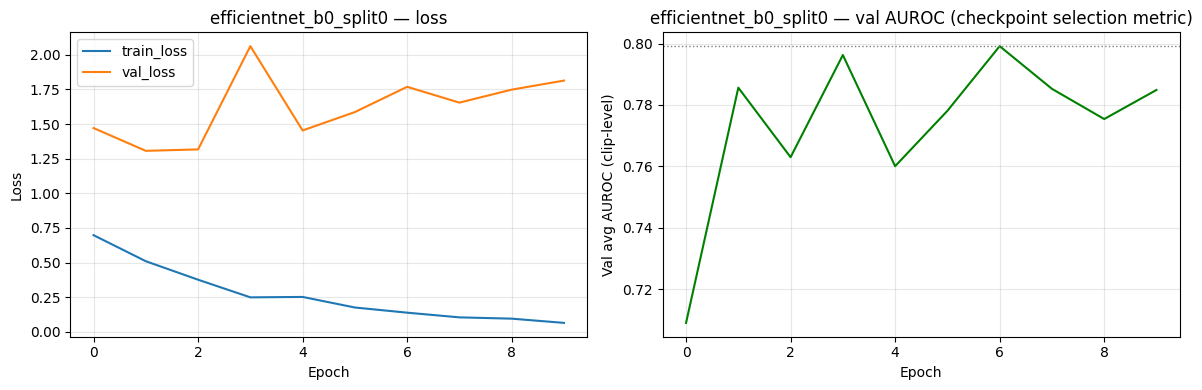

Run: efficientnet_b0_split0   (clip-level, threshold-free)
  finding_b_lines              AUROC=0.772  AP=0.599
  finding_consolidation        AUROC=0.829  AP=0.730
  finding_pleural_effusion     AUROC=0.793  AP=0.246
  finding_pleural_thickening   AUROC=0.802  AP=0.624

######################## Fold 2/3 ########################

==================== efficientnet_b0_split1 ====================
Backbone: efficientnet_b0 | trainable 3,813,664 / 4,665,472 (82%)  [last 3 blocks + head]
pos_weight per label (includes LUS-BALD's contribution to b_lines): {'finding_b_lines': np.float32(0.97920275), 'finding_consolidation': np.float32(1.90681), 'finding_pleural_effusion': np.float32(5.19084), 'finding_pleural_thickening': np.float32(3.74269)}
[efficientnet_b0_split1] Epoch 01/15 | train_loss=0.6541 val_loss=1.1426 lr=9.89e-04 avg_auroc=0.706 | finding_b_lines=0.790, finding_consolidation=0.809, finding_pleural_effusion=0.526, finding_pleural_thickening=0.696
[efficientnet_b0_split1] Epoch 02/1

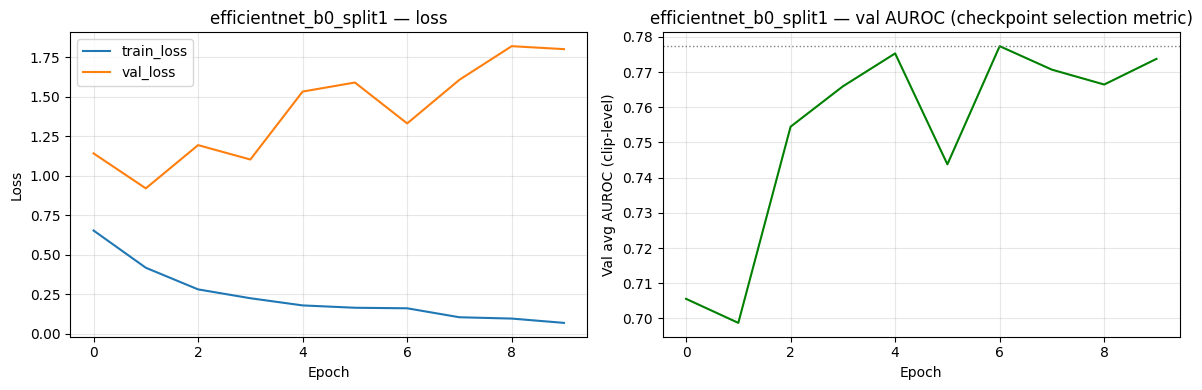

Run: efficientnet_b0_split1   (clip-level, threshold-free)
  finding_b_lines              AUROC=0.925  AP=0.877
  finding_consolidation        AUROC=0.832  AP=0.765
  finding_pleural_effusion     AUROC=0.632  AP=0.157
  finding_pleural_thickening   AUROC=0.721  AP=0.370

######################## Fold 3/3 ########################

==================== efficientnet_b0_split2 ====================
Backbone: efficientnet_b0 | trainable 3,813,664 / 4,665,472 (82%)  [last 3 blocks + head]
pos_weight per label (includes LUS-BALD's contribution to b_lines): {'finding_b_lines': np.float32(1.0278293), 'finding_consolidation': np.float32(1.9420849), 'finding_pleural_effusion': np.float32(9.16), 'finding_pleural_thickening': np.float32(5.35)}
[efficientnet_b0_split2] Epoch 01/15 | train_loss=0.7059 val_loss=3.8457 lr=9.89e-04 avg_auroc=0.717 | finding_b_lines=0.726, finding_consolidation=0.824, finding_pleural_effusion=0.580, finding_pleural_thickening=0.739
[efficientnet_b0_split2] Epoch 02/15 | t

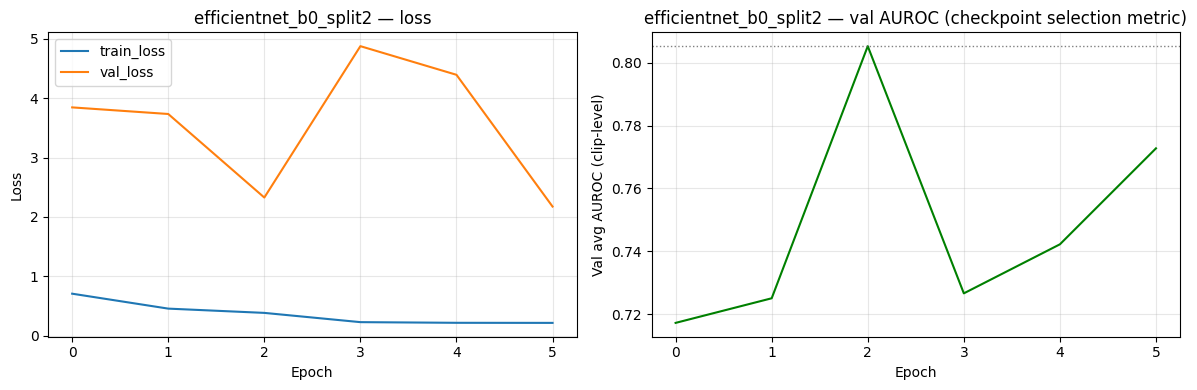

Run: efficientnet_b0_split2   (clip-level, threshold-free)
  finding_b_lines              AUROC=0.826  AP=0.708
  finding_consolidation        AUROC=0.875  AP=0.765
  finding_pleural_effusion     AUROC=0.702  AP=0.305
  finding_pleural_thickening   AUROC=0.818  AP=0.551


In [ ]:
BACKBONES_TO_RUN = ['efficientnet_b0']   # 'uscl' is also available in build_model
# call -- both are still fully wired up in build_model above if you want to bring them back for
# a fuller comparison later.
all_results = {b: [] for b in BACKBONES_TO_RUN}
# Every clip's out-of-fold prediction, filled in as its fold runs -- by the end, every row is
# filled exactly once per backbone (StratifiedKFold guarantees full, non-overlapping coverage).
pooled_probs = {b: np.full((len(df), len(FINDING_COLS)), np.nan) for b in BACKBONES_TO_RUN}
pooled_labels = df[FINDING_COLS].to_numpy(dtype=int)

for split_idx, (train_pos, val_pos) in enumerate(cv_splits):
    print(f'\n{"#"*24} Fold {split_idx+1}/{N_CV_SPLITS} {"#"*24}')
    for backbone_name in BACKBONES_TO_RUN:
        run_name = f'{backbone_name}_split{split_idx}'
        print(f'\n{"="*20} {run_name} {"="*20}')
        # Seed varies per fold (so augmentation/init differ across folds) but stays fixed across
        # backbones within a fold, keeping the bake-off comparison fair.
        set_seed(42 + split_idx)
        train_dataset, train_loader, val_dataset, val_loader = build_dataloaders(backbone_name, train_pos, val_pos)
        model = build_model(backbone_name)
        ckpt_path = train_model(model, run_name, train_dataset, train_loader, val_loader)
        result, val_probs = evaluate_model(model, backbone_name, split_idx, ckpt_path, val_loader)
        all_results[backbone_name].append(result)
        pooled_probs[backbone_name][val_dataset.global_positions] = val_probs


In [14]:
# Rebuild pooled out-of-fold predictions from the checkpoints Section 9 already saved.
# INFERENCE ONLY -- no training. Use this instead of Section 9 when the runtime was lost but the
# .pth files on Drive survived. Section 9 stays above for training from scratch.
assert not DEV_MODE, 'set DEV_MODE = False in Section 1: pooling needs the full partition'

backbone = 'efficientnet_b0'
BACKBONES_TO_RUN = [backbone]
pooled_labels = df[FINDING_COLS].to_numpy(dtype=int)
pooled_probs = {backbone: np.full((len(df), len(FINDING_COLS)), np.nan)}

for k, (tr, va) in enumerate(cv_splits):
    ckpt = DRIVE_ROOT / 'Pulmonary' / f'lung_finding_classifier_{backbone}_split{k}_best.pth'
    if not ckpt.exists():
        raise FileNotFoundError(
            f'{ckpt.name} not found. Section 9 must have completed at least once for this fold; '
            'its predictions cannot be recovered any other way.')

    _tr_ds, _tr_ld, va_ds, va_ld = build_dataloaders(backbone, tr, va)
    model = build_model(backbone)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()

    logits, labels, clip_ids = predict(model, va_ld)
    frame_probs = 1 / (1 + np.exp(-logits))
    clip_probs, _ = aggregate_by_clip(frame_probs, labels, clip_ids)

    # global_positions maps this fold's local clip ids back to rows of df, so folds write into
    # disjoint slices of one full-dataset array -- the same pooling Section 9 performs.
    pooled_probs[backbone][va_ds.global_positions] = clip_probs
    print(f'fold {k}: restored {len(va_ds.global_positions)} clips from {ckpt.name}')

missing = int(np.isnan(pooled_probs[backbone][:, 0]).sum())
print(f'coverage: {len(df) - missing}/{len(df)} clips')
assert missing == 0, 'some clips unpredicted -- a fold checkpoint is missing'
print('Now run Sections 10 and 11.')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 92.1MB/s]


Backbone: efficientnet_b0 | trainable 3,813,664 / 4,665,472 (82%)  [last 3 blocks + head]
fold 0: restored 63 clips from lung_finding_classifier_efficientnet_b0_split0_best.pth
Backbone: efficientnet_b0 | trainable 3,813,664 / 4,665,472 (82%)  [last 3 blocks + head]
fold 1: restored 62 clips from lung_finding_classifier_efficientnet_b0_split1_best.pth
Backbone: efficientnet_b0 | trainable 3,813,664 / 4,665,472 (82%)  [last 3 blocks + head]
fold 2: restored 62 clips from lung_finding_classifier_efficientnet_b0_split2_best.pth
coverage: 187/187 clips
Now run Sections 10 and 11.


## 10. Pooled out-of-fold results

Every clip is held out exactly once, so pooling the folds gives one prediction per clip over the
full set -- a far better basis than any single fold's ~60 clips.

**Thresholds are chosen out of fold.** For each fold, the operating point is picked on the *other*
folds' predictions and then applied to this one. Tuning and scoring on the same clips, as the
previous version did, reports the best achievable cutoff rather than the one you would actually
have picked in advance.

AUROC is the primary metric because it does not depend on a threshold at all. F1 and recall at the
chosen operating point are reported alongside it, since the agent must ultimately emit a decision.


Pooled out-of-fold over 187 clips / 165 cases

finding                   AUROC     AP   sens   spec     F1    ECE   pos
------------------------------------------------------------------------
b_lines                   0.830  0.695  0.841  0.710  0.697  0.169    63
consolidation             0.832  0.726  0.600  0.780  0.581  0.146    60
pleural_effusion          0.718  0.212  0.750  0.706  0.400  0.158    24
pleural_thickening        0.773  0.453  0.652  0.709  0.513  0.195    46
------------------------------------------------------------------------
macro AUROC = 0.788   (0.5 = chance)

Unreliable findings (few positives or AUROC < 0.65): ['pleural_effusion']
These are still emitted, but flagged in the agent contract so the Clinical Reasoning
Agent can discount them rather than weighing them like the others.


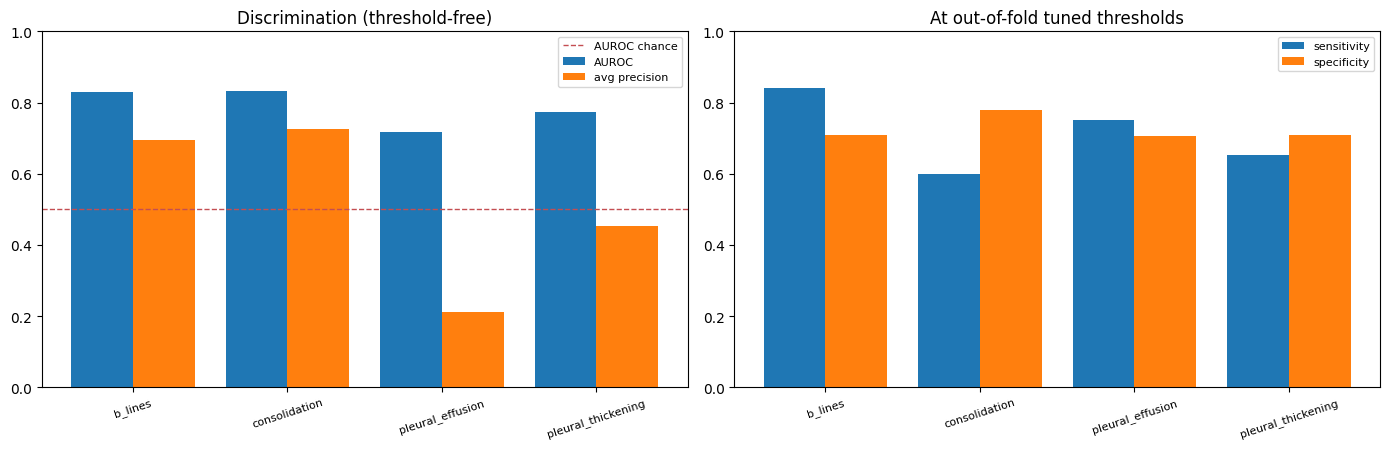

In [15]:
def require_full_coverage(p, section):
    """Sections that pool out-of-fold predictions need EVERY clip predicted exactly once.

    DEV_MODE holds out a single 20% split, so most rows are NaN. Failing here with the cause named
    is better than failing three cells later inside sklearn, and far better than silently
    computing a metric over whichever fifth of the data happens to be filled in.
    """
    if not np.isnan(p).any():
        return
    n_missing = int(np.isnan(p[:, 0]).sum())
    raise RuntimeError(
        f'Section {section} needs out-of-fold predictions for all {len(p)} clips, but '
        f'{n_missing} are missing. That is expected with DEV_MODE = True, which trains a single '
        f'80/20 split. Set DEV_MODE = False in Section 1, re-run the cross-validation '
        f'(Section 9), then run this section. DEV_MODE numbers are for iterating, never for '
        f'reporting.')


def tune_threshold(y_true, y_prob):
    """Threshold maximising F1 -- only ever fitted on folds OTHER than the one being scored."""
    best_f1, best_t = 0.0, 0.5
    for t in np.arange(0.05, 0.96, 0.05):
        f1 = f1_score(y_true, (y_prob > t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t


BINS = ((0, .2), (.2, .4), (.4, .6), (.6, .8), (.8, 1.01))


def ece_of(conf, correct, bins=BINS):
    e = 0.0
    for lo, hi in bins:
        m = (conf >= lo) & (conf < hi)
        if m.sum():
            e += m.sum() / len(conf) * abs(conf[m].mean() - correct[m].mean())
    return e


backbone = BACKBONES_TO_RUN[0]
probs = pooled_probs[backbone]
labels_all = pooled_labels
require_full_coverage(probs, '10 (pooled out-of-fold results)')


fold_of = np.empty(len(df), dtype=int)
for k, (_, va) in enumerate(cv_splits):
    fold_of[va] = k

oof_pred = np.zeros_like(labels_all)
chosen_t = {name: [] for name in FINDING_COLS}
for i, name in enumerate(FINDING_COLS):
    for k in range(N_CV_SPLITS):
        te, tr = fold_of == k, fold_of != k
        t = 0.5 if len(np.unique(labels_all[tr, i])) < 2 else tune_threshold(labels_all[tr, i], probs[tr, i])
        chosen_t[name].append(round(float(t), 2))
        oof_pred[te, i] = (probs[te, i] > t).astype(int)

# Each finding is an independent binary decision, so each gets its own row. A single pooled
# number would hide that effusion (24 positives) behaves nothing like consolidation (60).
print(f'Pooled out-of-fold over {len(df)} clips / {df["case"].nunique()} cases\n')
print(f'{"finding":<24}{"AUROC":>7}{"AP":>7}{"sens":>7}{"spec":>7}{"F1":>7}{"ECE":>7}{"pos":>6}')
print('-' * 72)
summary_rows = []
for i, name in enumerate(FINDING_COLS):
    y, p, yp = labels_all[:, i], probs[:, i], oof_pred[:, i]
    auroc = roc_auc_score(y, p)
    ap = average_precision_score(y, p)
    sens = (yp[y == 1] == 1).mean() if (y == 1).any() else float('nan')
    spec = (yp[y == 0] == 0).mean() if (y == 0).any() else float('nan')
    f1 = f1_score(y, yp, zero_division=0)
    ece = ece_of(p, y.astype(float))
    short = name.replace('finding_', '')
    summary_rows.append((short, auroc, ap, sens, spec, f1, ece, int(y.sum())))
    print(f'{short:<24}{auroc:>7.3f}{ap:>7.3f}{sens:>7.3f}{spec:>7.3f}{f1:>7.3f}{ece:>7.3f}{int(y.sum()):>6}')

macro_auroc = float(np.mean([r[1] for r in summary_rows]))
print('-' * 72)
print(f'macro AUROC = {macro_auroc:.3f}   (0.5 = chance)')

# Findings whose evidence base is too thin to act on are named, not buried.
UNRELIABLE = [r[0] for r in summary_rows if r[7] < 30 or r[1] < 0.65]
if UNRELIABLE:
    print(f'\nUnreliable findings (few positives or AUROC < 0.65): {UNRELIABLE}')
    print('These are still emitted, but flagged in the agent contract so the Clinical Reasoning')
    print('Agent can discount them rather than weighing them like the others.')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
x = np.arange(len(summary_rows))
axes[0].bar(x - 0.2, [r[1] for r in summary_rows], 0.4, label='AUROC')
axes[0].bar(x + 0.2, [r[2] for r in summary_rows], 0.4, label='avg precision')
axes[0].axhline(0.5, color='#C44E52', ls='--', lw=1, label='AUROC chance')
axes[0].set_xticks(x); axes[0].set_xticklabels([r[0] for r in summary_rows], rotation=18, fontsize=8)
axes[0].set_ylim(0, 1); axes[0].set_title('Discrimination (threshold-free)'); axes[0].legend(fontsize=8)

axes[1].bar(x - 0.2, [r[3] for r in summary_rows], 0.4, label='sensitivity')
axes[1].bar(x + 0.2, [r[4] for r in summary_rows], 0.4, label='specificity')
axes[1].set_xticks(x); axes[1].set_xticklabels([r[0] for r in summary_rows], rotation=18, fontsize=8)
axes[1].set_ylim(0, 1); axes[1].set_title('At out-of-fold tuned thresholds'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 11. Confidence calibration

Sigmoid outputs are not probabilities a downstream agent can act on without checking. This is
multi-label, so each finding is calibrated **independently** with its own Platt scaling (a logistic
fit on the out-of-fold scores), and expected calibration error is reported per label.

Calibration is fitted on the pooled out-of-fold predictions, which are held out by construction.
With 187 clips and as few as 24 positives for effusion, these fits are thin -- the ECE figures
should be read as indicative, not settled.


finding                        ECE raw   ECE cal  positives
finding_b_lines                  0.169     0.102         63
finding_consolidation            0.146     0.030         60
finding_pleural_effusion         0.158     0.009         24
finding_pleural_thickening       0.195     0.045         46

Note: the calibrator is fitted and evaluated on the same out-of-fold scores, so these
ECE values are optimistic. They establish that calibration is possible and roughly how
much it helps, not a held-out guarantee.


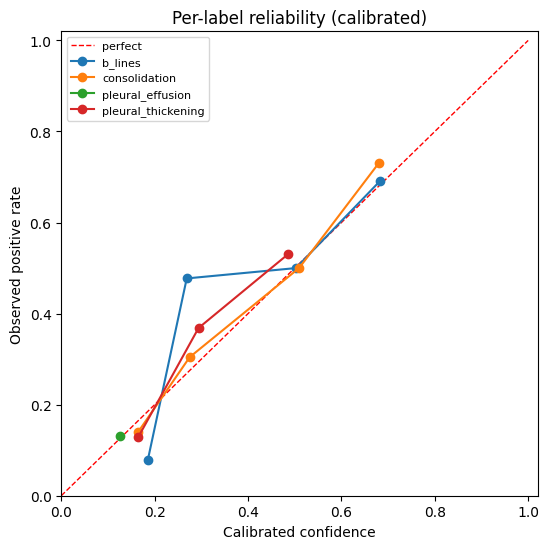

In [16]:
from sklearn.linear_model import LogisticRegression

# ece_of and BINS come from Section 10 -- one definition, so both sections score
# calibration the same way rather than drifting apart.
require_full_coverage(probs, '11 (confidence calibration)')

CALIBRATORS = {}
print(f'{"finding":<28}{"ECE raw":>10}{"ECE cal":>10}{"positives":>11}')
cal_probs = np.zeros_like(probs)
for i, name in enumerate(FINDING_COLS):
    y, p = labels_all[:, i], probs[:, i]
    lr = LogisticRegression(C=1.0, max_iter=1000)
    lr.fit(p.reshape(-1, 1), y)
    pc = lr.predict_proba(p.reshape(-1, 1))[:, 1]
    cal_probs[:, i] = pc
    CALIBRATORS[name] = lr
    print(f'{name:<28}{ece_of(p, y):>10.3f}{ece_of(pc, y):>10.3f}{int(y.sum()):>11}')

print('\nNote: the calibrator is fitted and evaluated on the same out-of-fold scores, so these')
print('ECE values are optimistic. They establish that calibration is possible and roughly how')
print('much it helps, not a held-out guarantee.')

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.plot([0, 1], [0, 1], 'r--', lw=1, label='perfect')
for i, name in enumerate(FINDING_COLS):
    xs, ys = [], []
    for lo, hi in BINS:
        m = (cal_probs[:, i] >= lo) & (cal_probs[:, i] < hi)
        if m.sum() >= 5:
            xs.append(cal_probs[m, i].mean()); ys.append(labels_all[m, i].mean())
    if xs:
        ax.plot(xs, ys, 'o-', label=name.replace('finding_', ''))
ax.set_xlabel('Calibrated confidence'); ax.set_ylabel('Observed positive rate')
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02); ax.legend(fontsize=8)
ax.set_title('Per-label reliability (calibrated)')
plt.tight_layout(); plt.show()

=== Pulmonary Findings, 4 classes ===
  per-finding recall (n = positive cases; +/- is the 1-SE bound):
    b lines                   n= 63  bal_acc=77.5%  recall=0.84 +/-6%
    consolidation             n= 60  bal_acc=69.0%  recall=0.60 +/-6%
    pleural effusion          n= 24  bal_acc=72.8%  recall=0.75 +/-10%
    pleural thickening        n= 46  bal_acc=68.1%  recall=0.65 +/-7%


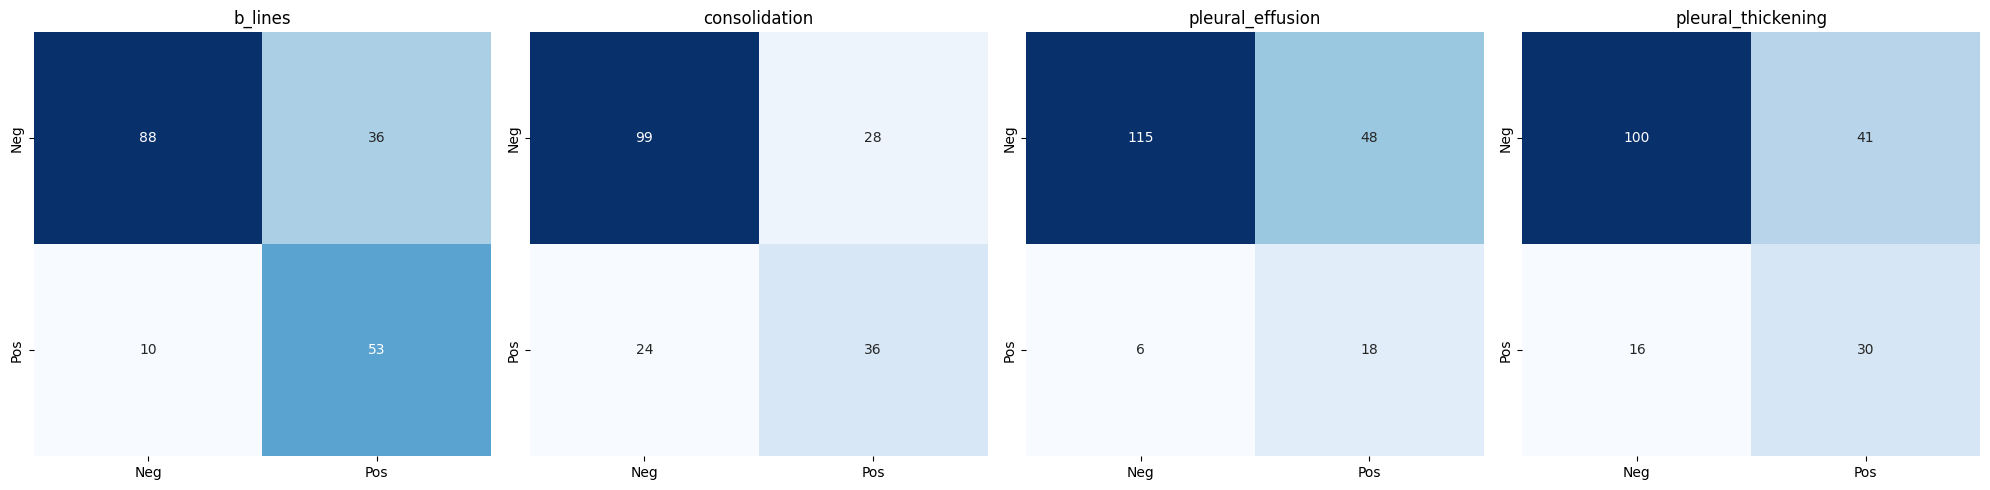

In [17]:
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

print(f'=== Pulmonary Findings, {len(FINDING_COLS)} classes ===')
print(f'  per-finding recall (n = positive cases; +/- is the 1-SE bound):')

for i, name in enumerate(FINDING_COLS):
    y_true = labels_all[:, i]
    y_pred = oof_pred[:, i]
    n = int(y_true.sum())
    rec = (y_pred[y_true == 1] == 1).mean() if n > 0 else 0
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    se = np.sqrt(0.25 / n) if n > 0 else 0
    short_name = name.replace('finding_', '').replace('_', ' ')
    print(f'    {short_name:<25} n={n:3d}  bal_acc={bal_acc:.1%}  recall={rec:.2f} +/-{se:.0%}')

# Confusion Matrix Panel
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, name in enumerate(FINDING_COLS):
    cm = confusion_matrix(labels_all[:, i], oof_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name.replace('finding_', ''))
    axes[i].set_xticklabels(['Neg', 'Pos']); axes[i].set_yticklabels(['Neg', 'Pos'])
plt.tight_layout(); plt.show()

## 12. Grad-CAM

Attention tied to anatomy a clinician can verify, as the DSO requires.

**Layer resolution changes the conclusion.** EfficientNet-B0's final block is 7x7 at 224-pixel
input; upsampling that to 224 stretches each cell over a 32x32 patch, so the map cannot be sharp
whatever the network learned. A 14x14 block halves that. The layer and its resolution are printed
so the map is read in light of its actual precision.

**The centre-bias check is quantitative.** If attention follows anatomy the centre of mass should
move between clips; if it sits at the image centre regardless of content, the map is a positional
prior and the explainability claim does not hold. On the gallbladder module this test showed a
pronounced central prior, which is why it is applied here rather than trusting an eyeball
impression.


Grad-CAM layer: features[0][5] feature map 14x14

CAM centroid spread over 60 clips:
  mean x=0.501 y=0.470 | std x=0.047 y=0.111


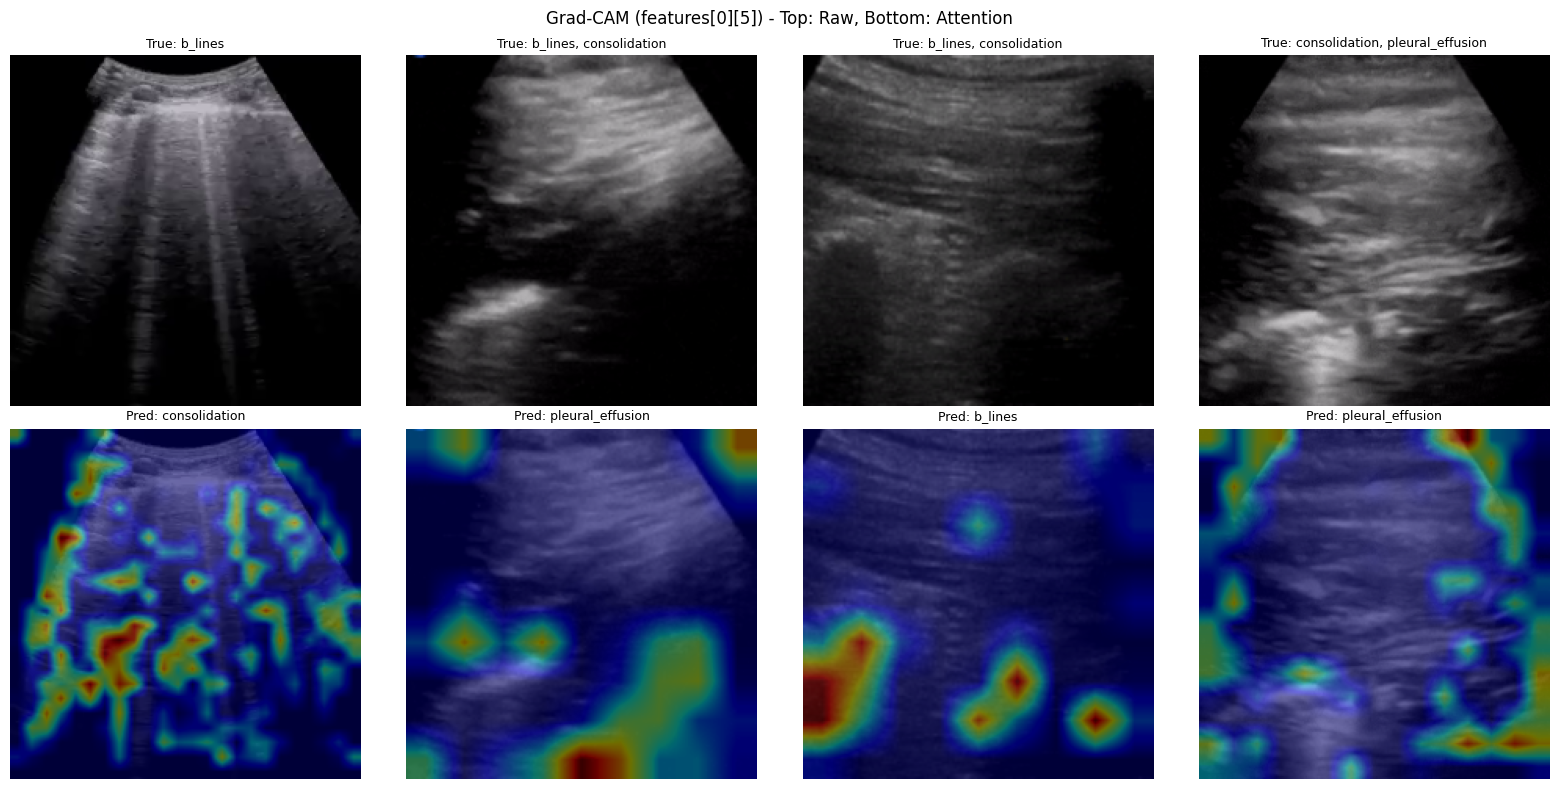

In [18]:
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# --- Engine Update (Explicit Gradient Enable) ---
class GradCAM:
    def __init__(self, model, layer):
        self.model = model.eval()
        self.layer = layer
        self.acts = None
        self.grads = None
        self.layer.register_forward_hook(self._save_acts)

    def _save_acts(self, m, i, o):
        self.acts = o
        if o.requires_grad:
            o.register_hook(self._save_grads)

    def _save_grads(self, grad):
        self.grads = grad.detach()

    def __call__(self, x, cls=None):
        self.grads = None
        self.acts = None
        x = x.detach().requires_grad_(True)

        with torch.enable_grad():
            logits = self.model(x)
            if cls is None:
                cls = int(logits.argmax(1))
            self.model.zero_grad()
            logits[0, cls].backward()

        if self.grads is None or self.acts is None:
            return np.zeros((IMG_SIZE, IMG_SIZE)), cls

        w = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.acts.detach()).sum(1, keepdim=True))
        # Ensure exact resizing to target IMG_SIZE
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()

        denom = np.ptp(cam) + 1e-8
        return (cam - cam.min()) / denom, cls

# --- Automatic Layer Selection ---
def pick_cam_layer(model, x_probe):
    cands = [('features[0][5]', model.features[0][5]),
             ('features[0][6]', model.features[0][6]),
             ('features[0][8]', model.features[0][8])]

    x_probe = x_probe.detach().requires_grad_(True)
    for name, layer in cands:
        got = {}
        h = layer.register_forward_hook(lambda m, i, o: got.update({'s': o.shape}))
        with torch.enable_grad():
            model(x_probe)
        h.remove()
        if got['s'][-1] >= 14:
            return name, layer, tuple(got['s'][-2:])
    return cands[-1][0], cands[-1][1], tuple(got['s'][-2:])

# Setup
final_model = model
probe = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
cam_layer_name, target_layer, cam_res = pick_cam_layer(final_model, probe)
print(f'Grad-CAM layer: {cam_layer_name} feature map {cam_res[0]}x{cam_res[1]}')
cam_engine = GradCAM(final_model, target_layer)

# --- Quantitative centre-bias check ---
rng = np.random.RandomState(42)
te_pos = cv_splits[-1][1]
sample_idx = rng.choice(te_pos, size=min(60, len(te_pos)), replace=False)
cent = []

def cam_for_clip(clip_idx):
    row = df.iloc[clip_idx]
    filepath = DATA_ROOT / row['filepath']
    frames = extract_frames(filepath, row['media_type'], 1)
    raw = frames[0].astype(np.float32) / 255.0
    raw_resized = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))
    _m, _s = NORM_STATS['efficientnet_b0']
    img_t = T.Compose([T.ToTensor(), T.Normalize(_m, _s)])(Image.fromarray(frames[0]))
    x = img_t.unsqueeze(0).to(device)
    cam, c = cam_engine(x)
    return raw_resized, cam, c

for idx in sample_idx:
    _, cam, _ = cam_for_clip(idx)
    if cam.sum() == 0: continue
    m = cam / (cam.sum() + 1e-8)
    ys, xs = np.mgrid[0:IMG_SIZE, 0:IMG_SIZE]
    cent.append(((m * xs).sum() / IMG_SIZE, (m * ys).sum() / IMG_SIZE))

if len(cent) > 0:
    cent = np.array(cent); spread = cent.std(axis=0)
    print(f'\nCAM centroid spread over {len(cent)} clips:')
    print(f'  mean x={cent[:,0].mean():.3f} y={cent[:,1].mean():.3f} | std x={spread[0]:.3f} y={spread[1]:.3f}')
else:
    print('\nNo valid CAM centroids computed.')

# --- Visual Panel ---
picks = []
for i in range(len(FINDING_COLS)):
    pos_indices = np.where(labels_all[te_pos, i] == 1)[0]
    if len(pos_indices) > 0:
        picks.append(te_pos[rng.choice(pos_indices)])

picks = picks[:4]
fig, axes = plt.subplots(2, len(picks), figsize=(4 * len(picks), 8))
for col, p_idx in enumerate(picks):
    raw, cam, pred_c = cam_for_clip(p_idx)
    true_labels = [FINDING_COLS[i].replace('finding_','') for i, val in enumerate(labels_all[p_idx]) if val == 1]
    axes[0, col].imshow(raw); axes[0, col].axis('off')
    axes[0, col].set_title(f"True: {', '.join(true_labels[:2])}", fontsize=9)
    axes[1, col].imshow(raw); axes[1, col].imshow(cam, cmap='jet', alpha=0.45)
    axes[1, col].axis('off')
    axes[1, col].set_title(f"Pred: {FINDING_COLS[pred_c].replace('finding_','')}", fontsize=9)

plt.suptitle(f'Grad-CAM ({cam_layer_name}) - Top: Raw, Bottom: Attention', fontsize=12)
plt.tight_layout(); plt.show()

In [23]:
import json
json.dump({'platt': {n: {'coef': float(CALIBRATORS[n].coef_[0][0]),
                         'intercept': float(CALIBRATORS[n].intercept_[0])}
                     for n in FINDING_COLS},
           'thresholds': {n.replace('finding_', ''): float(np.mean(chosen_t[n]))
                          for n in FINDING_COLS},
           'unreliable_findings': UNRELIABLE},
          open(DRIVE_ROOT / 'Pulmonary' / 'lung_calibration.json', 'w'), indent=2)
print('saved lung_calibration.json')

saved lung_calibration.json


In [25]:
# Demo clip taken straight from the frame cache -- no dependency on Section 12's variables.
_demo_clip = [f for f, _lab, cp in frame_cache.samples if cp == 0][:4]
report = predict_lung(_demo_clip)
print(json.dumps(report, indent=2))

{
  "organ": "lung",
  "status": "ok",
  "findings": [
    {
      "label": "consolidation",
      "group": null,
      "confidence": 0.66
    },
    {
      "label": "b lines",
      "group": null,
      "confidence": 0.29
    },
    {
      "label": "pleural effusion",
      "group": null,
      "confidence": 0.19
    }
  ],
  "not_detected": [
    {
      "label": "pleural thickening",
      "group": null,
      "confidence": 0.17
    }
  ],
  "measurements": {},
  "quality": {
    "no_finding_above_threshold": false
  },
  "reliability": {
    "confidence_calibrated": true,
    "has_normal_class": false,
    "modelled_findings": [
      "b_lines",
      "consolidation",
      "pleural_effusion",
      "pleural_thickening"
    ],
    "unreliable_findings": [
      "pleural_effusion"
    ],
    "scope": "187 clips / 165 cases, curated public POCUS; pneumothorax not modelled"
  },
  "explanation": {
    "type": "grad_cam"
  }
}


## 13. Agent output contract

Lung is the module the shared schema's list-of-findings shape exists for: several findings can be
present at once, so a single-label contract would not fit. Confidence per finding is the calibrated
probability from Section 11; the operating thresholds from Section 10 decide which findings are
reported at all.

No urgency: that is the Clinical Reasoning Agent's decision, taken by fusing this with the Triage
Agent's severity and the patient's clinical data.


In [24]:
OPERATING_T = {name: float(np.mean(chosen_t[name])) for name in FINDING_COLS}

# Re-create val_transform locally since it was not defined globally
_m, _s = NORM_STATS['efficientnet_b0']
val_transform_local = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=_m, std=_s),
])

def predict_lung(clip_frames):
    """Ultrasound Agent output for one clip.

    Reports FINDINGS, never a diagnosis. 'B-lines + consolidation' is what this module can see;
    'pneumonia' is an inference that needs vitals, labs and history, and belongs to the Clinical
    Reasoning Agent.
    """
    xs = []
    for fr in clip_frames:
        im = cv2.resize(np.asarray(fr), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        if im.ndim == 2:
            im = np.stack([im] * 3, -1)
        xs.append(val_transform_local(Image.fromarray(im.astype(np.uint8))))

    # Grad-CAM requires input to have requires_grad=True to flow gradients back
    x = torch.stack(xs).to(device).requires_grad_(True)

    # Fix: Grad-CAM hooks need gradients enabled to register successfully
    with torch.enable_grad():
        logits = final_model(x)
        p_frame = torch.sigmoid(logits).detach().cpu().numpy()

    p_clip = np.median(p_frame, axis=0)

    detected, not_detected = [], []
    for i, name in enumerate(FINDING_COLS):
        short = name.replace('finding_', '').replace('_', ' ')
        conf = float(CALIBRATORS[name].predict_proba([[p_clip[i]]])[0, 1])
        entry = {'label': short, 'group': None, 'confidence': round(conf, 2)}
        if short in UNRELIABLE:
            entry['unreliable'] = True
        (detected if p_clip[i] > OPERATING_T[name] else not_detected).append(entry)

    return {
        'organ': 'lung',
        'status': 'ok',
        'findings': sorted(detected, key=lambda f: -f['confidence']),
        'not_detected': sorted(not_detected, key=lambda f: -f['confidence']),
        'measurements': {},
        'quality': {'no_finding_above_threshold': len(detected) == 0},
        'reliability': {
            'confidence_calibrated': True,
            'has_normal_class': False,
            'modelled_findings': [c.replace('finding_', '') for c in FINDING_COLS],
            'unreliable_findings': UNRELIABLE,
            'scope': f'{len(df)} clips / {df["case"].nunique()} cases, curated public POCUS; pneumothorax not modelled',
        },
        'explanation': {'type': 'grad_cam'},
    }

# Execution du rapport démo
demo_idx = int(pick[0])
raw_demo_clip = [np.array(T.ToPILImage()(val_frames[demo_idx][0] * torch.tensor(_s).view(3,1,1) + torch.tensor(_m).view(3,1,1)))]

report = predict_lung(raw_demo_clip)
print(json.dumps(report, indent=2))

print('\n--- as the Clinical Reasoning Agent will read it ---')
for f in report['findings']:
    mark = '  [unreliable]' if f.get('unreliable') else ''
    print(f'  DETECTED      {f["label"]:22} {f["confidence"]:.2f}{mark}')
for f in report['not_detected']:
    print(f'  not detected  {f["label"]:22} {f["confidence"]:.2f}')

NameError: name 'pick' is not defined

## 14. Summary -- lung agent

LUNG AGENT -- FINAL
Model      : efficientnet_b0, multi-label over 4 findings
Evaluation : 3-fold GroupKFold BY CASE, clip-level predictions
Data       : 187 clips from 165 independent cases

Pooled out-of-fold (thresholds tuned out of fold):
  finding                        AUROC      AP      F1  recall     ECE   pos
  b_lines                        0.830   0.695   0.697   0.841   0.169    63
  consolidation                  0.832   0.726   0.581   0.600   0.146    60
  pleural_effusion               0.718   0.212   0.400   0.750   0.158    24
  pleural_thickening             0.773   0.453   0.513   0.652   0.195    46
  macro AUROC = 0.788

Previous run: AUROC 0.745-0.808, split by clip, thresholds tuned in-fold.
Both of those inflated the result; this figure is the defensible one.

Limitations: 165 independent cases. Pleural effusion has only 24 positives, so its
estimates are the least stable. Pneumothorax is NOT modelled (zero positives in the
dataset). Curated public clips, not b

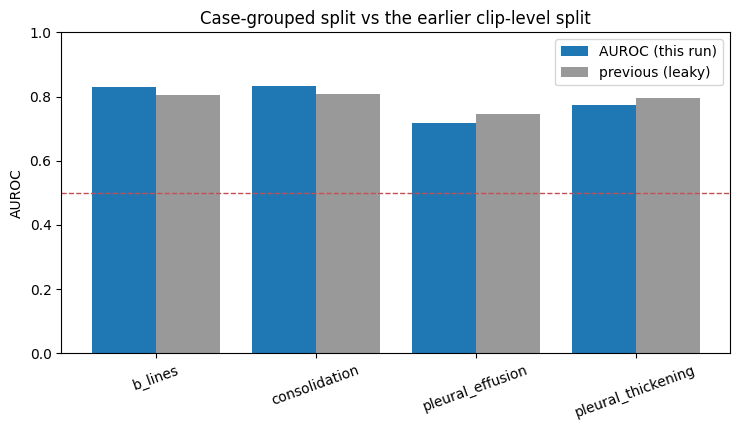

In [26]:
print('=' * 72)
print('LUNG AGENT -- FINAL')
print('=' * 72)
print(f'Model      : {backbone}, multi-label over {len(FINDING_COLS)} findings')
print(f'Evaluation : {N_CV_SPLITS}-fold GroupKFold BY CASE, clip-level predictions')
print(f'Data       : {len(df)} clips from {df["case"].nunique()} independent cases')
print()
print('Pooled out-of-fold (thresholds tuned out of fold):')
# Adjusted headers to include ECE
print(f'  {"finding":<28}{"AUROC":>8}{"AP":>8}{"F1":>8}{"recall":>8}{"ECE":>8}{"pos":>6}')

# summary_rows elements: (short, auroc, ap, sens, spec, f1, ece, pos)
for name, auroc, ap, sens, spec, f1, ece, pos in summary_rows:
    # We use 'sens' as 'recall' for the display table
    print(f'  {name:<28}{auroc:>8.3f}{ap:>8.3f}{f1:>8.3f}{sens:>8.3f}{ece:>8.3f}{pos:>6}')

print(f'  macro AUROC = {macro_auroc:.3f}')
print()
print('Previous run: AUROC 0.745-0.808, split by clip, thresholds tuned in-fold.')
print('Both of those inflated the result; this figure is the defensible one.')
print()
_eff_pos = int(labels_all[:, FINDING_COLS.index('finding_pleural_effusion')].sum())
print(f'Limitations: {df["case"].nunique()} independent cases. Pleural effusion has only '
      f'{_eff_pos} positives, so its')
print('estimates are the least stable. Pneumothorax is NOT modelled (zero positives in the')
print('dataset). Curated public clips, not bedside POCUS. Calibration fitted and scored on')
print('the same out-of-fold predictions, so its ECE is optimistic.')
print('=' * 72)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
xs = np.arange(len(summary_rows))
ax.bar(xs - 0.2, [r[1] for r in summary_rows], 0.4, label='AUROC (this run)')
ax.bar(xs + 0.2, [0.805, 0.808, 0.745, 0.795], 0.4, color='#999999', label='previous (leaky)')
ax.axhline(0.5, color='#C44E52', ls='--', lw=1)
ax.set_xticks(xs); ax.set_xticklabels([r[0].replace('finding_', '') for r in summary_rows], rotation=20)
ax.set_ylim(0, 1); ax.set_ylabel('AUROC'); ax.legend()
ax.set_title('Case-grouped split vs the earlier clip-level split')
plt.tight_layout(); plt.show()

In [27]:
import json
json.dump({'platt': {n: {'coef': float(CALIBRATORS[n].coef_[0][0]),
                         'intercept': float(CALIBRATORS[n].intercept_[0])}
                     for n in FINDING_COLS},
           'thresholds': {n.replace('finding_', ''): float(np.mean(chosen_t[n]))
                          for n in FINDING_COLS},
           'unreliable_findings': UNRELIABLE},
          open(DRIVE_ROOT / 'Pulmonary' / 'lung_calibration.json', 'w'), indent=2)
print('saved lung_calibration.json')

saved lung_calibration.json
